In [15]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

X_train = pd.read_csv('../data/processed/X_train_processed.csv')
X_test = pd.read_csv('../data/processed/X_test_processed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [ ]:
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

log_reg_model.fit(X_train, y_train)

print("Логистическая регрессия обучена!")

Логистическая регрессия обучена!



Отчет классификации для логистической регрессии:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     21049
           1       0.15      0.68      0.24      1355

    accuracy                           0.74     22404
   macro avg       0.56      0.71      0.54     22404
weighted avg       0.92      0.74      0.81     22404


ROC-AUC Score: 0.7760


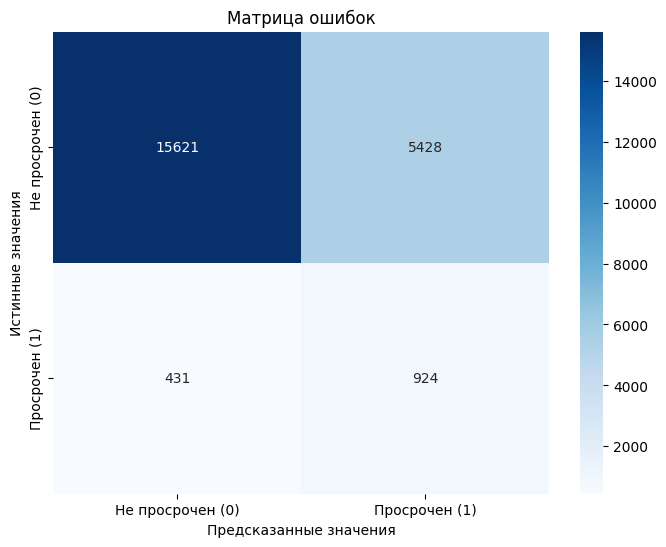

In [17]:
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

print("\nОтчет классификации для логистической регрессии:")
print(classification_report(y_test, y_pred_log_reg))

roc_auc = roc_auc_score(y_test, y_pred_proba_log_reg)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Не просрочен (0)', 'Просрочен (1)'], yticklabels=['Не просрочен (0)', 'Просрочен (1)'])
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

In [18]:
joblib.dump(log_reg_model, '../models/logistic_model.pkl')
print("Модель логистической регрессии сохранена!")

Модель логистической регрессии сохранена!


In [19]:
import json

results = {
    'LogisticRegression': {
        'roc_auc_score': roc_auc,
        'classification_report': classification_report(y_test, y_pred_log_reg, output_dict=True)
    }
}

output_path = '../models/training_results.json'
with open(output_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"Метрики для Логистической регрессии сохранены в {output_path}")

Метрики для Логистической регрессии сохранены в ../models/training_results.json


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Инициализируем модель Случайного леса

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

print("Модель Случайного леса обучена!")

Модель Случайного леса обучена!


In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nОтчет классификации для Случайного леса:")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nROC-AUC Score: {roc_auc_rf:.4f}")


Отчет классификации для Случайного леса:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     21049
           1       0.53      0.10      0.18      1355

    accuracy                           0.94     22404
   macro avg       0.74      0.55      0.57     22404
weighted avg       0.92      0.94      0.92     22404


ROC-AUC Score: 0.8126


In [ ]:
import json
import joblib

joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("Модель Случайного леса сохранена!")

with open('../models/training_results.json', 'r') as f:
    all_results = json.load(f)

all_results['RandomForestClassifier'] = {
    'roc_auc_score': roc_auc_rf,
    'classification_report': classification_report(y_test, y_pred_rf, output_dict=True)
}

with open('../models/training_results.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Метрики для Случайного леса добавлены в training_results.json")

Модель Случайного леса сохранена!
Метрики для Случайного леса добавлены в training_results.json


In [23]:
import lightgbm as lgb
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
# Инициализируем модель LightGBM

lgb_model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')


lgb_model.fit(X_train, y_train)

print("Модель LightGBM обучена!")

[LightGBM] [Info] Number of positive: 5419, number of negative: 84197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 964
[LightGBM] [Info] Number of data points in the train set: 89616, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Модель LightGBM обучена!



Отчет классификации для LightGBM:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     21049
           1       0.19      0.73      0.30      1355

    accuracy                           0.80     22404
   macro avg       0.59      0.77      0.59     22404
weighted avg       0.93      0.80      0.85     22404


ROC-AUC Score: 0.8430


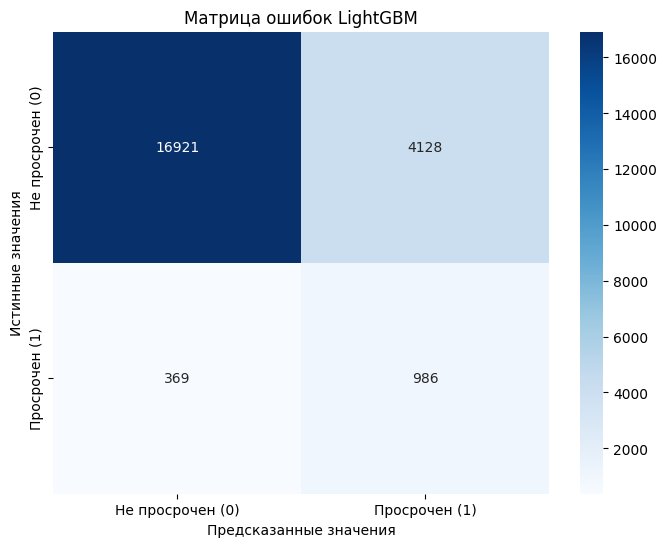

In [ ]:
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]


print("\nОтчет классификации для LightGBM:")
print(classification_report(y_test, y_pred_lgb))


roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"\nROC-AUC Score: {roc_auc_lgb:.4f}")

cm_lgb = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не просрочен (0)', 'Просрочен (1)'],
            yticklabels=['Не просрочен (0)', 'Просрочен (1)'])
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок LightGBM')
plt.show()

In [ ]:
joblib.dump(lgb_model, '../models/lightgbm_model.pkl')
print("Модель LightGBM сохранена!")

with open('../models/training_results.json', 'r') as f:
    all_results = json.load(f)


all_results['LightGBM'] = {
    'roc_auc_score': roc_auc_lgb,
    'classification_report': classification_report(y_test, y_pred_lgb, output_dict=True)
}

with open('../models/training_results.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Метрики для LightGBM добавлены в training_results.json")

Модель LightGBM сохранена!
Метрики для LightGBM добавлены в training_results.json


In [ ]:
best_model = joblib.load('../models/lightgbm_model.pkl')

joblib.dump(best_model, '../models/best_model.pkl')
print("Лучшая модель сохранена как best_model.pkl!")

Лучшая модель сохранена как best_model.pkl!
